In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim

random.seed(24)
np.random.seed(24)

### CUDA Setup

In [2]:
device = torch.device("cuda")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
torch.cuda.manual_seed(24)

Using device: cuda
GPU: NVIDIA GeForce RTX 2080 Super with Max-Q Design
VRAM: 8.6 GB


---
## Markov Decision Process (MDP) Framework

In [3]:
class GridWorld:
    """
    A simple 4x4 GridWorld MDP.
    State: (row, col). Goal: reach (3,3). Pit: (2,2).
    Actions: 0=Up, 1=Down, 2=Left, 3=Right
    """
    def __init__(self, size=4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.goal = (size-1, size-1)
        self.pit = (size//2, size//2)
        self.action_effects = [(-1,0),(1,0),(0,-1),(0,1)]  # U D L R

    def state_id(self, s): return s[0]*self.size + s[1]
    def state_xy(self, sid): return (sid // self.size, sid % self.size)

    def reset(self):
        self.pos = (0, 0)
        return self.state_id(self.pos)

    def step(self, action):
        dr, dc = self.action_effects[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)
        done = False
        if self.pos == self.goal:
            reward, done = +10.0, True
        elif self.pos == self.pit:
            reward, done = -10.0, True
        else:
            reward = -0.1  # small step penalty encourages efficiency
        return self.state_id(self.pos), reward, done

env = GridWorld()
print(f"GridWorld: {env.n_states} states, {env.n_actions} actions")
print(f"Goal state id: {env.state_id(env.goal)}, Pit state id: {env.state_id(env.pit)}")

GridWorld: 16 states, 4 actions
Goal state id: 15, Pit state id: 10


---
## Deep Q-Network (DQN)

DQN extends Q-learning to large/continuous state spaces using:
1. **Neural network** to approximate $Q(s,a;\theta)$
2. **Experience replay buffer** $\mathcal{B}$ to break temporal correlations
3. **Target network** $Q(\cdot;\theta^-)$ updated every $T_\text{target}$ steps

Loss:
$$L_\text{DQN}(\theta, \theta^-) = \frac{1}{B} \sum_{i=1}^B \bigl\| Q(s_i,a_i;\theta) - \tilde{Y}_i^Q \bigr\|_2^2,
\quad \tilde{Y}_i^Q = r_i + \gamma \max_{a'} Q(s'_i,a';\theta^-)$$

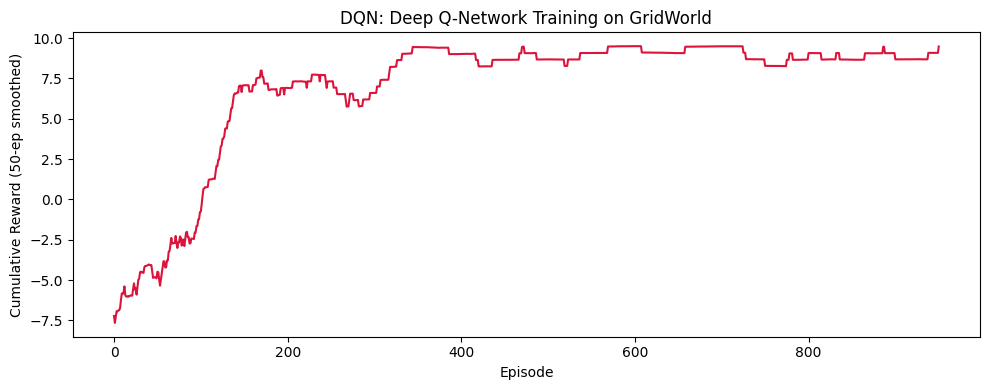

DQN final smoothed reward: 9.474


In [4]:

class QNetwork(nn.Module):
    """Fully-connected Q-network: state -> Q-values for all actions"""
    def __init__(self, n_states, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x): return self.net(x)


class ReplayBuffer:
    """Experience replay buffer B - stores transitions on CPU, moves to device on sample"""
    def __init__(self, capacity=10000):
        self.buf = deque(maxlen=capacity)
    def push(self, s, a, r, s_next, done):
        self.buf.append((s, a, r, s_next, done))
    def sample(self, batch_size, device):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s_next, done = zip(*batch)
        # Handle both int actions (DQN) and float actions (DDPG)
        try:
            a_t = torch.LongTensor(list(a))
        except (TypeError, ValueError):
            a_t = torch.FloatTensor(np.array(list(a), dtype=np.float32))
        # Move all tensors to the target device (GPU)
        return (
            torch.FloatTensor(np.array(list(s), dtype=np.float32)).to(device),
            a_t.to(device),
            torch.FloatTensor(np.array(list(r), dtype=np.float32)).to(device),
            torch.FloatTensor(np.array(list(s_next), dtype=np.float32)).to(device),
            torch.FloatTensor(np.array(list(done), dtype=np.float32)).to(device),
        )
    def __len__(self): return len(self.buf)


def dqn(env, num_episodes=1000, gamma=0.99, lr=1e-3, batch_size=64, buffer_capacity=10000,
        epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995, target_update_freq=20):
    """
    Deep Q-Network (DQN) - CUDA-enabled.
    Uses experience replay & target network for stable training.
    State is one-hot encoded for the tabular GridWorld environment.
    Both networks live on device (GPU).
    """
    n_s, n_a = env.n_states, env.n_actions

    # Move networks to GPU
    q_net  = QNetwork(n_s, n_a).to(device)
    tgt_net = QNetwork(n_s, n_a).to(device)   # Target network theta^-
    tgt_net.load_state_dict(q_net.state_dict())
    tgt_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    replay = ReplayBuffer(buffer_capacity)

    epsilon = epsilon_start
    cum_rewards = []

    def encode(s):
        """One-hot state encoding - returns a CPU numpy array (moved to GPU in batch)"""
        v = np.zeros(n_s)
        v[s] = 1.0
        return v

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        total_r = 0

        while not done:
            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                a = np.random.randint(n_a)
            else:
                with torch.no_grad():
                    # Move single state tensor to GPU for inference
                    state_t = torch.FloatTensor(encode(s)).to(device)
                    q_vals  = q_net(state_t)
                a = q_vals.argmax().item()    # scalar back to CPU automatically

            s_next, r, done = env.step(a)
            total_r += r
            replay.push(encode(s), a, r, encode(s_next), float(done))
            s = s_next

            # Train when replay buffer has enough samples
            if len(replay) >= batch_size:
                # Sample batch — tensors are already on `device`
                s_b, a_b, r_b, sn_b, d_b = replay.sample(batch_size, device)

                # Current Q-values (computed on GPU)
                q_curr = q_net(s_b).gather(1, a_b.unsqueeze(1)).squeeze()

                # Target Q-values using frozen target network (on GPU)
                with torch.no_grad():
                    q_tgt = r_b + gamma * tgt_net(sn_b).max(1)[0] * (1 - d_b)

                # DQN loss - backprop runs on GPU
                loss = nn.MSELoss()(q_curr, q_tgt)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Update target network every T_target episodes
        if ep % target_update_freq == 0:
            tgt_net.load_state_dict(q_net.state_dict())

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        cum_rewards.append(total_r)

    return q_net, cum_rewards


dqn_net, rewards_dqn = dqn(env, num_episodes=1000)

window = 50
smooth_dqn = np.convolve(rewards_dqn, np.ones(window)/window, mode='valid')
plt.figure(figsize=(10, 4))
plt.plot(smooth_dqn, color='crimson')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward (50-ep smoothed)')
plt.title('DQN: Deep Q-Network Training on GridWorld')
plt.tight_layout()
plt.show()
print(f"DQN final smoothed reward: {smooth_dqn[-1]:.3f}")